# RESTOPS · Find financial trends and product economics

In [1]:
from pathlib import Path
import json
import os
import sys

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from src.common import read, TABLEAU, REPORTS
from src.reporting import style
style()
pd.set_option("display.max_columns", 12)


**Business question:** Where do sales and contribution come from, and does growth translate to profit?

Recalculate rates from summed inputs. Use location peers and comparable periods rather than treating all stores as identical.

In [2]:
monthly = read("store_month_kpis")
chain = monthly.groupby("month")[["revenue", "operating_profit", "transactions", "labour_cost"]].sum()
chain["margin"] = chain.operating_profit / chain.revenue
chain.tail(6)

,revenue,operating_profit,transactions,labour_cost,margin
month,,,,,
2025-07,1366041.89,104193.168571,30414,522393.00,0.076274
2025-08,1505063.45,200328.060000,31742,542665.35,0.133103
2025-09,1470874.84,191092.560000,31217,530463.85,0.129918
2025-10,1645838.65,214619.930000,36138,595560.20,0.130402
2025-11,1691448.69,221937.080000,37330,609511.85,0.131211
2025-12,1776441.13,282751.440001,37633,627034.60,0.159167


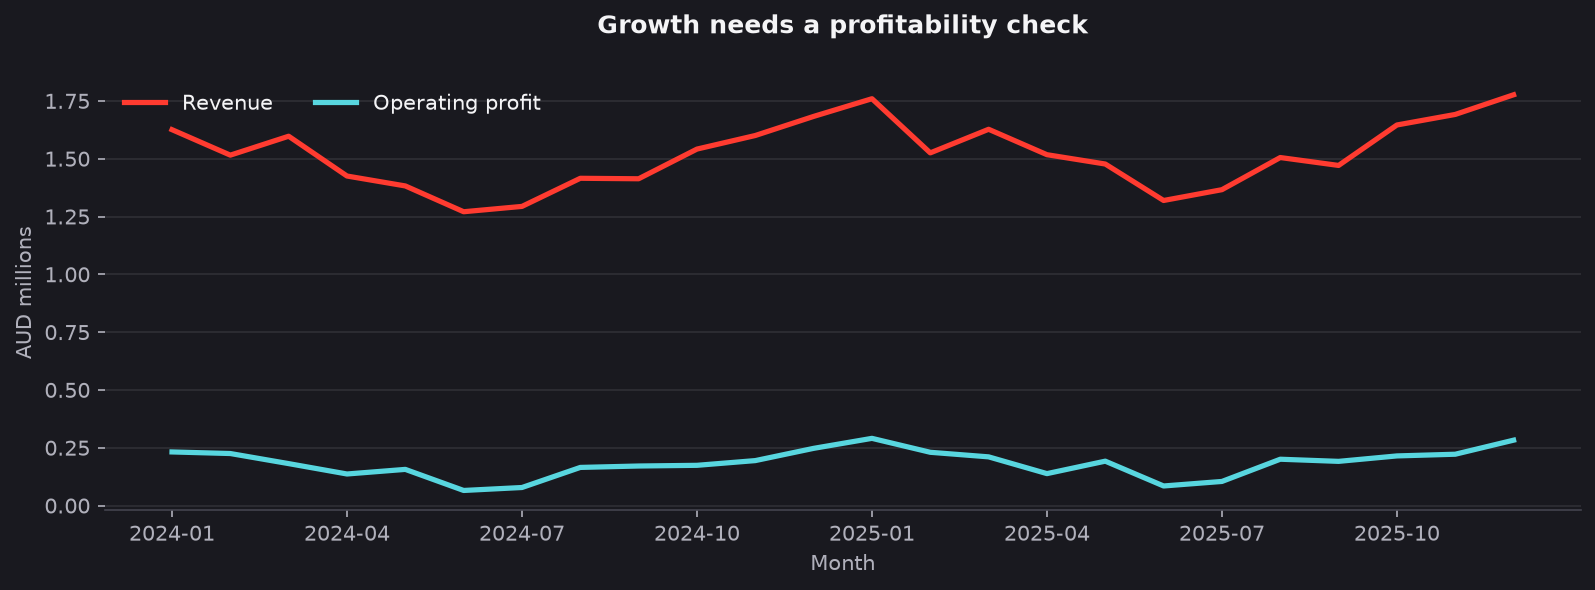

In [3]:
display(Image(filename=str(REPORTS / "figures/executive_trend.png")))

In [4]:
products = read("product_month", TABLEAU)
category = products.groupby("category")[["revenue", "ingredient_cost", "gross_contribution", "units"]].sum()
category["gross_margin"] = category.gross_contribution / category.revenue
category.sort_values("gross_contribution", ascending=False)

,revenue,ingredient_cost,gross_contribution,units,gross_margin
category,,,,,
Mains,24027275.00,8378741.41,15648533.59,993767,0.651282
Salads,4108932.67,1273817.56,2835115.11,213576,0.689988
Drinks,2974541.69,660597.14,2313944.55,505626,0.777916
Sides,2971856.47,715079.03,2256777.44,369140,0.759383
Desserts,2361987.97,674362.48,1687625.49,233864,0.714494


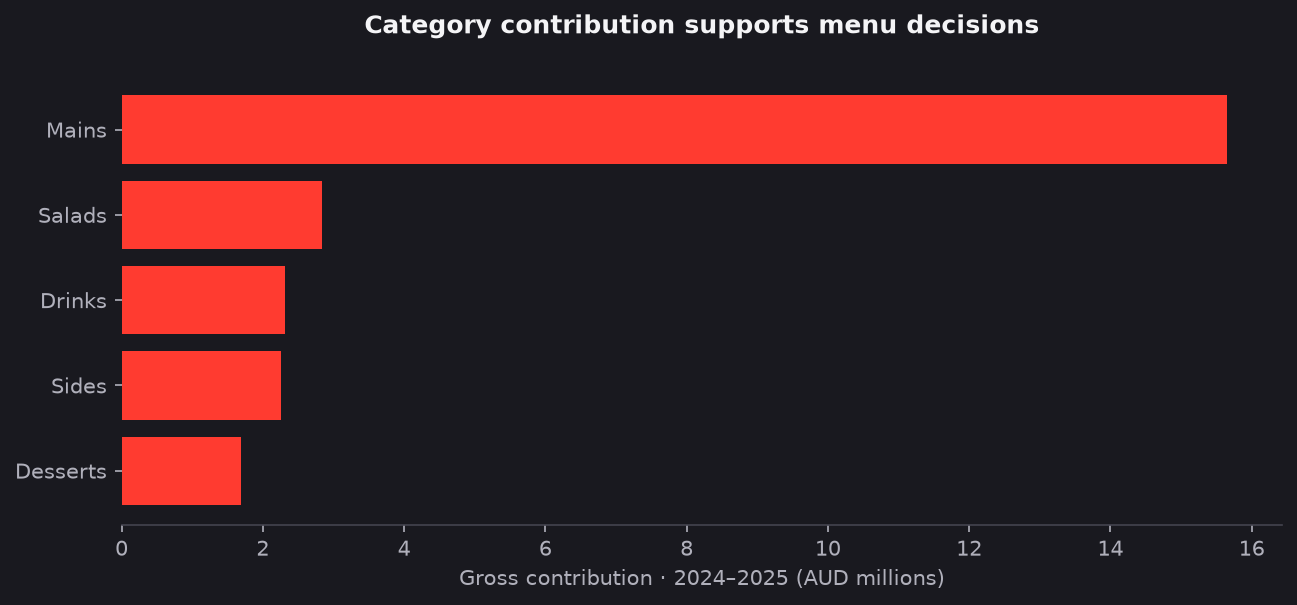

In [5]:
display(Image(filename=str(REPORTS / "figures/product_contribution.png")))

### Verify through SQL
This query aggregates independent facts before joining; it is a useful safeguard against repeated labour and waste costs.

In [6]:
import sqlite3
with sqlite3.connect(ROOT / "data/processed/restops.sqlite") as connection:
    sql_kpis = pd.read_sql_query((ROOT / "sql/kpi_queries.sql").read_text(), connection)
sql_kpis.head()

,restaurant_id,month,revenue,transactions,average_transaction_value,gross_margin_pct,labour_cost_pct,sales_per_labour_hour,waste_pct,satisfaction_score,responses,target_achievement_pct
0,1,2024-01,97239.0,2110,46.084834,0.685578,0.344288,103.776948,0.031659,4.354651,172,0.872714
1,1,2024-02,97496.0,2120,45.988679,0.686438,0.310618,112.064368,0.035192,4.378882,161,0.935366
2,1,2024-03,95338.4,2091,45.594644,0.678924,0.350830,103.628696,0.032965,4.201389,144,0.855656
3,1,2024-04,88102.6,1923,45.815185,0.677933,0.345361,104.386967,0.027261,4.350365,137,0.817072
4,1,2024-05,85374.0,1854,46.048544,0.686116,0.334915,103.924528,0.029667,4.346154,156,0.766226


In [7]:
insights = json.loads((REPORTS / "insights.json").read_text())
print(insights[4]["what"])
print(insights[4]["action"])

Mains generated 63.2% of gross contribution, while Drinks had the highest category ingredient margin.
Operations and Marketing: test one complementary add-on bundle; evaluate basket contribution, uptake and service time.


**Decision:** Evaluate menu changes using contribution as well as sales. Ingredient margin alone does not capture preparation labour, delivery commissions or cannibalisation.